In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

100%|██████████| 522M/522M [00:02<00:00, 205MB/s]

Extracting files...


In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.random import set_seed

from sklearn.model_selection import train_test_split

In [3]:
print(path)  # tumne jo download kiya

# folder ke andar files dekho
print(os.listdir(path))


/root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2
['stocks', 'symbols_valid_meta.csv', 'etfs']


In [4]:
import os

print(os.listdir(os.path.join(path, "stocks"))[:10])

['MBCN.csv', 'PBA.csv', 'NWLI.csv', 'PIH.csv', 'DDS.csv', 'IFFT.csv', 'DB.csv', 'NFIN.csv', 'MTX.csv', 'SINA.csv']


In [5]:
df = pd.read_csv(os.path.join(path, "stocks", "ATH.csv"))
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-08-19,108.0,109.0,108.0,109.0,109.0,2800
1,2016-08-22,109.0,109.0,108.5,108.5,108.5,3634
2,2016-08-23,108.0,108.0,108.0,108.0,108.0,30
3,2016-08-24,109.0,110.0,109.0,110.0,110.0,1924
4,2016-08-25,108.0,110.0,108.0,110.0,110.0,1480


In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [7]:
# take only High column values
data = df["High"].values

# convert 1D array into 2D array because scaler needs 2D input
data = data.reshape(-1,1)

In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [9]:
data = df[['Close']]
data.head()

,Close
0,109.0
1,108.5
2,108.0
3,110.0
4,110.0


In [10]:
data

,Close
0,109.000000
1,108.500000
2,108.000000
3,110.000000
4,110.000000
...,...
904,27.719999
905,25.690001
906,26.309999
907,24.820000


In [11]:

from tensorflow.keras.layers import Dense, SimpleRNN


# scale data
sc = MinMaxScaler()
data = sc.fit_transform(data)
data

array([[0.89627557],
       [0.89145118],
       [0.88662678],
       [0.90592435],
       [0.90592435],
       [0.90592435],
       [0.90592435],
       [0.90592435],
       [0.90592435],
       [0.89868776],
       [0.9001351 ],
       [0.90592435],
       [0.91557314],
       [0.92522192],
       [0.92425706],
       [0.92425706],
       [0.92425706],
       [0.91557314],
       [0.91557314],
       [0.91557314],
       [0.91557314],
       [0.92522192],
       [0.95368581],
       [0.95416827],
       [0.95416827],
       [0.95416827],
       [1.        ],
       [0.99276341],
       [0.95416827],
       [0.95416827],
       [0.95416827],
       [0.93487071],
       [0.93487071],
       [0.90592435],
       [0.90592435],
       [0.90592435],
       [0.90592435],
       [0.89627557],
       [0.89627557],
       [0.89627557],
       [0.90109996],
       [0.90544188],
       [0.90544188],
       [0.89627557],
       [0.89627557],
       [0.86732922],
       [0.85044384],
       [0.838

In [12]:
# empty list for input sequences
X = []

# empty list for output values
y = []

# use previous 60 days data to predict next day
n_steps = 60

# loop starts from day 60 to last row
for i in range(n_steps, len(data)):

    # store previous 60 values in X
    X.append(data[i-n_steps:i])

    # store next value in y
    y.append(data[i])

# convert list into numpy array
X = np.array(X)

# convert list into numpy array
y = np.array(y)

In [13]:
X

array([[[0.89627557],
        [0.89145118],
        [0.88662678],
        ...,
        [0.8953107 ],
        [0.84803165],
        [0.89627557]],

       [[0.89145118],
        [0.88662678],
        [0.90592435],
        ...,
        [0.84803165],
        [0.89627557],
        [0.86829408]],

       [[0.88662678],
        [0.90592435],
        [0.90592435],
        ...,
        [0.89627557],
        [0.86829408],
        [0.86781168]],

       ...,

       [[0.30335777],
        [0.29862988],
        [0.29776149],
        ...,
        [0.0904091 ],
        [0.11202237],
        [0.09243535]],

       [[0.29862988],
        [0.29776149],
        [0.29805094],
        ...,
        [0.11202237],
        [0.09243535],
        [0.09841759]],

       [[0.29776149],
        [0.29805094],
        [0.30007718],
        ...,
        [0.09243535],
        [0.09841759],
        [0.0840409 ]]])

In [14]:
y

array([[0.86829408],
       [0.86781168],
       [0.86781168],
       [0.86781168],
       [0.86732922],
       [0.86829408],
       [0.8953107 ],
       [0.876978  ],
       [0.92232726],
       [0.92039753],
       [0.88855651],
       [0.88855651],
       [0.88662678],
       [0.86732922],
       [0.86732922],
       [0.876978  ],
       [0.90592435],
       [0.26958702],
       [0.28357776],
       [0.2831918 ],
       [0.28666537],
       [0.29708608],
       [0.29332302],
       [0.28579698],
       [0.28309533],
       [0.28541102],
       [0.29795447],
       [0.29554227],
       [0.29708608],
       [0.29641067],
       [0.29911231],
       [0.30760325],
       [0.30596294],
       [0.30798918],
       [0.29998071],
       [0.29920879],
       [0.29737553],
       [0.29544577],
       [0.28743729],
       [0.29071788],
       [0.297472  ],
       [0.2889811 ],
       [0.2905249 ],
       [0.28888459],
       [0.29158627],
       [0.29177922],
       [0.29187573],
       [0.298

In [15]:
# train test split (time series, no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train

array([[[0.89627557],
        [0.89145118],
        [0.88662678],
        ...,
        [0.8953107 ],
        [0.84803165],
        [0.89627557]],

       [[0.89145118],
        [0.88662678],
        [0.90592435],
        ...,
        [0.84803165],
        [0.89627557],
        [0.86829408]],

       [[0.88662678],
        [0.90592435],
        [0.90592435],
        ...,
        [0.89627557],
        [0.86829408],
        [0.86781168]],

       ...,

       [[0.27692012],
        [0.27875337],
        [0.28328831],
        ...,
        [0.25482439],
        [0.25607874],
        [0.25540333]],

       [[0.27875337],
        [0.28328831],
        [0.28695482],
        ...,
        [0.25607874],
        [0.25540333],
        [0.25472788]],

       [[0.28328831],
        [0.28695482],
        [0.26225396],
        ...,
        [0.25540333],
        [0.25472788],
        [0.25028945]]])

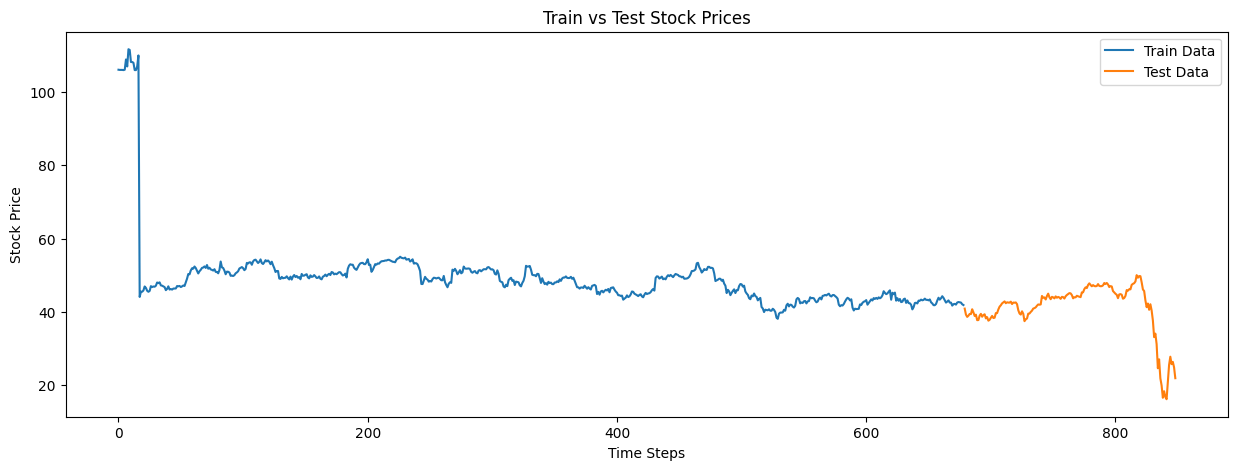

In [18]:
# inverse transform (scaled → original)
train_plot = sc.inverse_transform(y_train.reshape(-1,1))
test_plot = sc.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(15,5))

# Train data
plt.plot(range(len(train_plot)), train_plot, label="Train Data")

# Test data (train ke baad continue)
plt.plot(
    range(len(train_plot), len(train_plot) + len(test_plot)),
    test_plot,
    label="Test Data"
)

plt.title("Train vs Test Stock Prices")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

In [21]:

# build SIMPLE RNN model (from scratch style)
model = Sequential()

# RNN layer (this is the simplest recurrent network)
model.add(SimpleRNN(50, activation="tanh", input_shape=(60, 1)))

# output layer
model.add(Dense(1))

# compile model
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# train model
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0158
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0016
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013    
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013    
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011    
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012    
Ep

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step


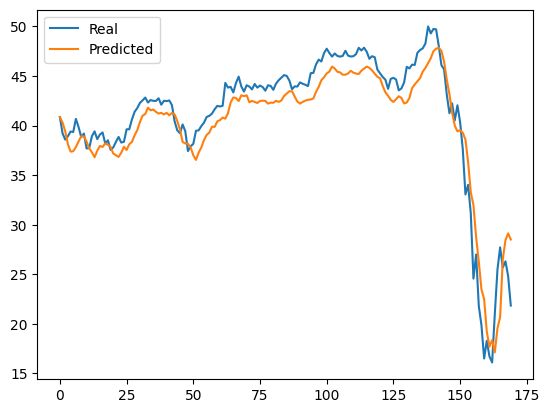

RMSE: 2.171842137335644


In [23]:


# prediction
pred = model.predict(X_test)

# convert back to original scale
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)

# plot results
plt.plot(real, label="Real")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()

# error
rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)

LSTM

In [24]:
model = Sequential()
model.add(LSTM(125, activation="tanh", input_shape=(60,1)))
model.add(Dense(1))

model.compile(optimizer="RMSprop", loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0104
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014    
Epoch 13/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014
Epoch 14/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013    
Epoch 15/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013    
Epoch 1

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


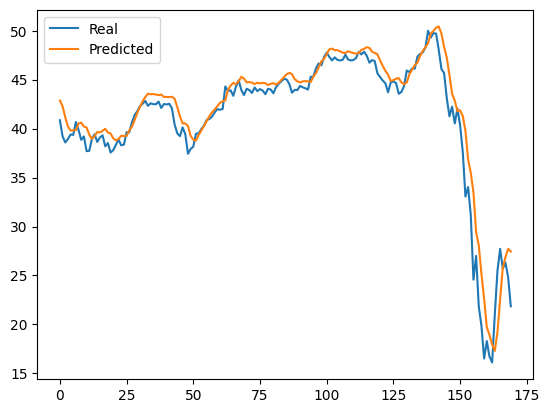

RMSE: 1.9196150197185202


In [26]:

# Prediction
pred = model.predict(X_test)
pred = sc.inverse_transform(pred)

real = sc.inverse_transform(y_test)

# Plot
plt.plot(real, label="Real")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)

In [27]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [28]:
y_test

array([[0.23880741],
       [0.22298341],
       [0.21690467],
       [0.22018526],
       [0.2247202 ],
       [0.22433424],
       [0.23707063],
       [0.22906212],
       [0.21941333],
       [0.22279043],
       [0.20831725],
       [0.20860671],
       [0.22018526],
       [0.22491314],
       [0.2173871 ],
       [0.22182553],
       [0.2238518 ],
       [0.21304514],
       [0.21622925],
       [0.20696643],
       [0.20928212],
       [0.21468545],
       [0.21950984],
       [0.21401004],
       [0.21478192],
       [0.22693941],
       [0.22693941],
       [0.2365882 ],
       [0.24392126],
       [0.2475878 ],
       [0.25260518],
       [0.25511384],
       [0.25781553],
       [0.25299114],
       [0.25540333],
       [0.25463141],
       [0.25453494],
       [0.25714008],
       [0.25086839],
       [0.25472788],
       [0.25434196],
       [0.25501737],
       [0.25038596],
       [0.23456192],
       [0.22587804],
       [0.22307988],
       [0.2316673 ],
       [0.225

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


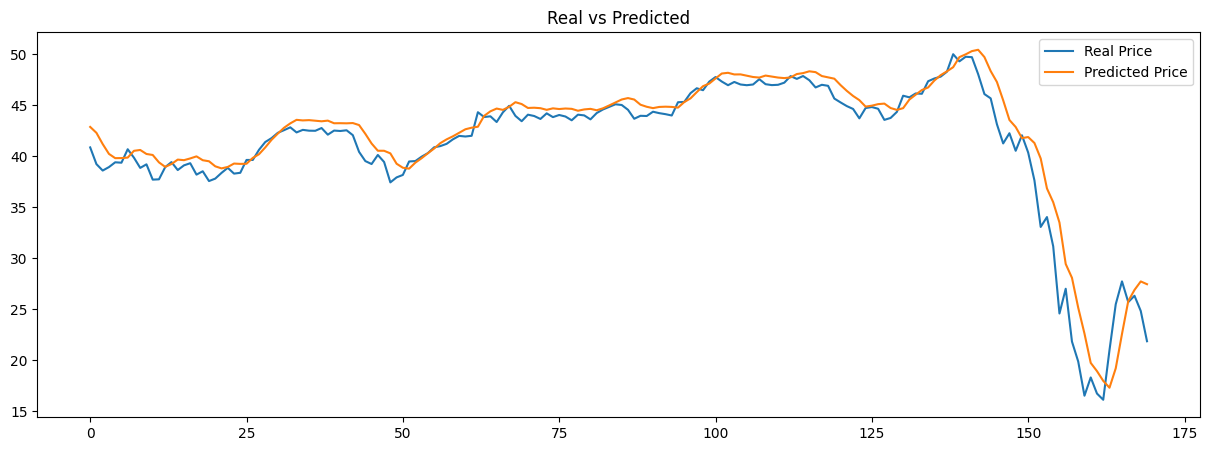

MSE  : 3.6849218239289345
RMSE : 1.9196150197185202
MAE  : 1.256581957199993
R2   : 0.921537848089544
MAPE : 3.8053950416977838 %


In [29]:

#  PREDICTION
pred = model.predict(X_test)

# inverse scaling
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)


#  PLOT RESULT
plt.figure(figsize=(15,5))

plt.plot(real, label="Real Price")
plt.plot(pred, label="Predicted Price")

plt.title("Real vs Predicted")
plt.legend()
plt.show()


# CALCULATE METRICS

# Mean Squared Error
mse = mean_squared_error(real, pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = mean_absolute_error(real, pred)

# R2 Score
r2 = r2_score(real, pred)

# Mean Absolute Percentage Error
mape = np.mean(np.abs((real - pred) / real)) * 100


#  PRINT METRICS
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("MAPE :", mape,"%")

In [30]:
pred

array([[42.869328],
       [42.288605],
       [41.188557],
       [40.224136],
       [39.807014],
       [39.814457],
       [39.86092 ],
       [40.525925],
       [40.608856],
       [40.215694],
       [40.118084],
       [39.39159 ],
       [38.949368],
       [39.23093 ],
       [39.664165],
       [39.608845],
       [39.778698],
       [39.98116 ],
       [39.603645],
       [39.499954],
       [39.006195],
       [38.803303],
       [38.942383],
       [39.275307],
       [39.243805],
       [39.257435],
       [39.82938 ],
       [40.194164],
       [40.859062],
       [41.601807],
       [42.21125 ],
       [42.78624 ],
       [43.21745 ],
       [43.563404],
       [43.507095],
       [43.534897],
       [43.483   ],
       [43.42095 ],
       [43.486828],
       [43.22814 ],
       [43.234623],
       [43.22258 ],
       [43.248417],
       [43.051495],
       [42.190434],
       [41.242176],
       [40.534378],
       [40.52991 ],
       [40.275177],
       [39.25878 ],


# # save full model (architecture + weights + optimizer)
# model.save("stock_rnn_model.h5")
# #or
# from tensorflow.keras.models import load_model

# model = load_model("stock_rnn_model.h5")

## **GRU**

In [31]:
model_gru = Sequential()
model_gru.add(GRU(units=125, activation="tanh", input_shape=(n_steps, 1)))
model_gru.add(Dense(units=1))
# Compiling the RNN
model_gru.compile(optimizer="RMSprop", loss="mse")

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 125)            │        48,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,126 (187.99 KB)

 Trainable params: 48,126 (187.99 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model_gru.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0042
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0016
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014    
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013    
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011
Epoch 13/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011    
Epoch 14/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010    
Epoch 15/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011
Ep

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


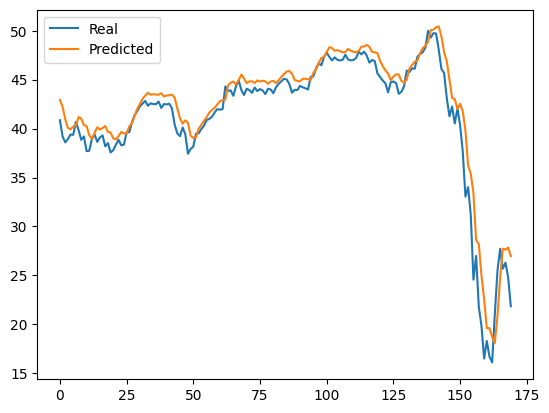

RMSE: 1.8893165728041112


In [33]:
pred = model_gru.predict(X_test)
pred = sc.inverse_transform(pred)

real = sc.inverse_transform(y_test)

# Plot
plt.plot(real, label="Real")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)